# Quality weight for each review

Each rating should count according to how useful other readers found the review.

$$h = \frac{\text{useful} + 2}{\text{total} + 4} \qquad w = \max\left(h^2 \cdot \sqrt{\log(1 + \text{total})},\ 0.1\right)$$

- **$h$ – smoothed helpfulness.** Adding 2 pseudo-votes on each side pulls reviews with few votes towards 50%, so 1 of 1 votes gives 0.6, not 100%.
- **$h^2$** – squaring makes usefulness the main driver: 0.9 → 0.81 while 0.35 → 0.12.
- **$\sqrt{\log(1 + \text{total})}$ – confidence.** More votes means more readers judged the review, but the number of votes is strongly damped so that attention alone does not buy influence.
- **minimum 0.1** – reviews with no votes still count a little.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from data_cleaning import load_and_clean
from weighting import helpfulness, review_weight

df = load_and_clean()
df["helpfulness"] = helpfulness(df)
df["weight"] = review_weight(df)

Loaded 2961 rows, kept 2761 with a valid rating, (200 dropped).


## Examples

In [2]:
examples = {
    "most voted review": df["total_votes"].idxmax(),
    "most voted 1-star": df[df["rating"] == 1]["total_votes"].idxmax(),
    "1 of 1 helpful": df[(df["total_votes"] == 1) & (df["useful_votes"] == 1)].index[0],
    "no votes": df[df["total_votes"] == 0].index[0],
}
df.loc[list(examples.values()), ["rating", "useful_votes", "total_votes", "helpfulness", "weight"]].set_axis(list(examples.keys())).round(2)

,rating,useful_votes,total_votes,helpfulness,weight
most voted review,10,1048,1171,0.89,2.12
most voted 1-star,1,112,306,0.37,0.32
1 of 1 helpful,8,1,1,0.60,0.30
no votes,10,0,0,0.50,0.10


- The most voted review (1,048 of 1,171 helpful) gets the largest weight, **2.12** – about 21× an unvoted review.
- The most voted 1-star review has many votes (306) but only 37% helpful, so it gets **0.32** – about the same as a review with a single helpful vote (**0.30**). Attention alone does not buy influence.
- A review with no votes gets the minimum **0.1**.

## Where does the weight go?

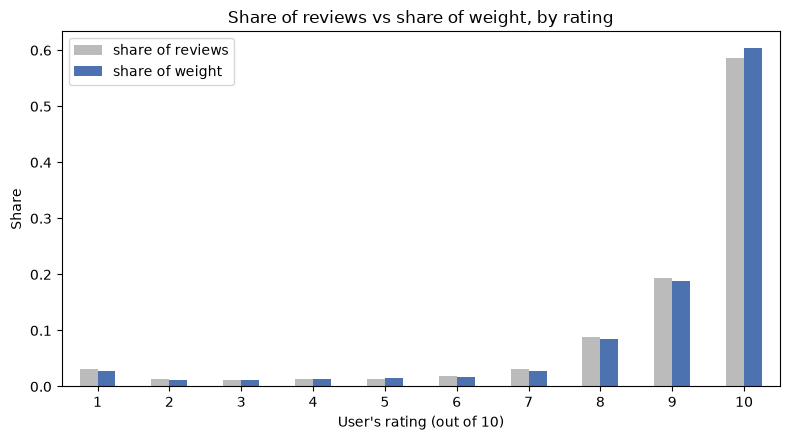

In [3]:
by_rating = pd.DataFrame({
    "share of reviews": df["rating"].value_counts(normalize=True),
    "share of weight": df.groupby("rating")["weight"].sum() / df["weight"].sum(),
}).sort_index()

ax = by_rating.plot.bar(figsize=(8, 4.5), color=["#BBBBBB", "#4C72B0"], rot=0)
ax.set_xlabel("User's rating (out of 10)")
ax.set_ylabel("Share")
ax.set_title("Share of reviews vs share of weight, by rating")
ax.figure.tight_layout()
plt.show()

- **10s gain a little** (58.6% of reviews → 60.4% of weight): many of the most helpful reviews are 10s.
- **1-star reviews lose a little** (3.2% → 2.8%): most readers voted them *not helpful*.
- The other ratings barely change, so the weighted rating (**8.92**) stays close to the plain average (**8.85**). On genuine reviews the weighting does not distort the result; its effect shows when unvoted mass ratings are added.